In [5]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [6]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    PROJECT_ROOT = CURRENT_DIR.parent

TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "archive-3" / "train"
TEST_DIR = PROJECT_ROOT / "data" / "raw" / "archive-3" / "test"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = (48, 48)
BATCH_SIZE = 64
SEED = 42

print("Train directory:", TRAIN_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Train directory: d:\Documents\DeepFER-Emotion-Recognition\data\raw\archive-3\train
Train exists: True
Test exists: True


In [7]:
train_dataset = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical"
)

validation_dataset = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [8]:
test_dataset = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names
number_of_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", number_of_classes)

Found 7178 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [11]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        )
    ],
    name="data_augmentation"
)

In [12]:
model = keras.Sequential(
    [
        layers.Input(shape=(48, 48, 1)),

        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.35),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.40),

        layers.Dense(number_of_classes, activation="softmax")
    ],
    name="DeepFER_CNN"
)

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "DeepFER_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             

 Total params: 424,071 (1.62 MB)

 Trainable params: 422,855 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [14]:
class_names_path = MODELS_DIR / "class_names.json"

with open(class_names_path, "w", encoding="utf-8") as file:
    json.dump(class_names, file, indent=4)

print("Class names saved to:", class_names_path)

Class names saved to: d:\Documents\DeepFER-Emotion-Recognition\models\class_names.json


In [15]:
model_path = MODELS_DIR / "deepfer_best.keras"
training_log_path = RESULTS_DIR / "training_log.csv"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        training_log_path
    )
]

In [16]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30


d:\Projects\music-genre-classification-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.2135 - loss: 2.1393
Epoch 1: val_accuracy improved from None to 0.18464, saving model to d:\Documents\DeepFER-Emotion-Recognition\models\deepfer_best.keras

Epoch 1: finished saving model to d:\Documents\DeepFER-Emotion-Recognition\models\deepfer_best.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 98s 176ms/step - accuracy: 0.2135 - loss: 2.1393 - val_accuracy: 0.1846 - val_loss: 2.3667 - learning_rate: 0.0010
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.2894 - loss: 1.8093
Epoch 2: val_accuracy improved from 0.18464 to 0.29768, saving model to d:\Documents\DeepFER-Emotion-Recognition\models\deepfer_best.keras

Epoch 2: finished saving model to d:\Documents\DeepFER-Emotion-Recognition\models\deepfer_best.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 55s 153ms/step - accuracy: 0.2894 - loss: 1.8093 - val_accuracy: 0.2977 - val_loss: 1.8139 - learning_rate: 0.0010
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.

In [17]:
final_model_path = MODELS_DIR / "deepfer_final.keras"
model.save(final_model_path)

print("Best model:", model_path)
print("Final model:", final_model_path)

Best model: d:\Documents\DeepFER-Emotion-Recognition\models\deepfer_best.keras
Final model: d:\Documents\DeepFER-Emotion-Recognition\models\deepfer_final.keras


In [18]:
best_model = keras.models.load_model(
    MODELS_DIR / "deepfer_best.keras"
)

test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.5839 - loss: 1.0876
Test loss: 1.0876
Test accuracy: 58.39%


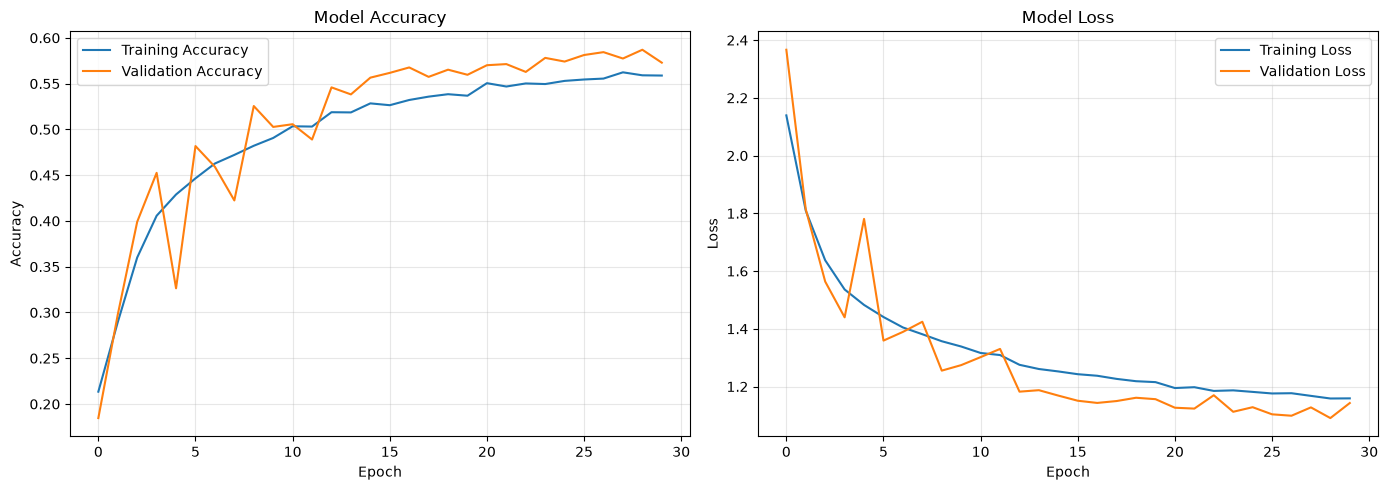

Chart saved to: d:\Documents\DeepFER-Emotion-Recognition\results\training_history.png


In [19]:
history_data = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_data["accuracy"], label="Training Accuracy")
axes[0].plot(history_data["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_data["loss"], label="Training Loss")
axes[1].plot(history_data["val_loss"], label="Validation Loss")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

history_chart_path = RESULTS_DIR / "training_history.png"
plt.savefig(history_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", history_chart_path)

In [20]:
import numpy as np

true_labels = []
predicted_labels = []

for images, labels in test_dataset:
    probabilities = best_model.predict(images, verbose=0)

    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    predicted_labels.extend(np.argmax(probabilities, axis=1))

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

print("Predictions generated:", len(predicted_labels))

Predictions generated: 7178


In [21]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    digits=4
)

print(report)

report_path = RESULTS_DIR / "classification_report.txt"
report_path.write_text(report, encoding="utf-8")

print("Report saved to:", report_path)

              precision    recall  f1-score   support

       angry     0.4480    0.5804    0.5057       958
     disgust     0.7143    0.0450    0.0847       111
        fear     0.4572    0.2559    0.3281      1024
       happy     0.8193    0.8151    0.8172      1774
     neutral     0.5096    0.6229    0.5606      1233
         sad     0.4356    0.4611    0.4480      1247
    surprise     0.7569    0.6968    0.7256       831

    accuracy                         0.5839      7178
   macro avg     0.5916    0.4967    0.4957      7178
weighted avg     0.5894    0.5839    0.5757      7178

Report saved to: d:\Documents\DeepFER-Emotion-Recognition\results\classification_report.txt


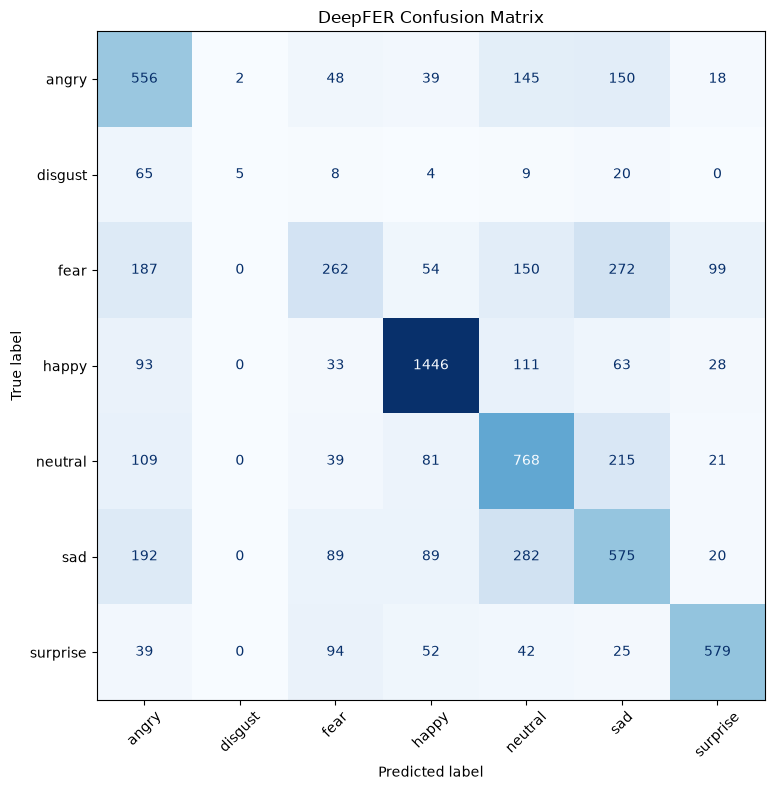

Confusion matrix saved to: d:\Documents\DeepFER-Emotion-Recognition\results\confusion_matrix.png


In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

matrix = confusion_matrix(true_labels, predicted_labels)

fig, ax = plt.subplots(figsize=(10, 8))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names
)

display_matrix.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("DeepFER Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()

matrix_path = RESULTS_DIR / "confusion_matrix.png"
plt.savefig(matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", matrix_path)